# Trabalho de Conclusão de Curso - Comparação de técnicas de Aprendizado de Máquina na previsão da direção dos retornos de ações do Ibovespa

Graduation Thesis - Comparing Machine Learning techniques on predicting the direction of returns of Ibovespa stocks

Luís Henrique Carvalho da Cruz - lhcc@cesar.school

## Importing Data and Python libraries

In [1333]:
# data
import pandas as pd
import plotly.express as px
from pandas import Timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# math
import numpy as np
import math
from math import floor, ceil

# stats, metrics, model selection
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import kstest, shapiro
from statsmodels.tsa.stattools import adfuller, pacf, acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# models
import pmdarima as pm
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

RANDOM_STATE = 21  # my age now lol

In [1334]:
abev3 = pd.read_csv("./stocks/ABEV3.csv")
bbdc3 = pd.read_csv("./stocks/BBDC3.csv")
itsa3 = pd.read_csv("./stocks/ITSA3.csv")
itub3 = pd.read_csv("./stocks/ITUB3.csv")
wege3 = pd.read_csv("./stocks/WEGE3.csv")

Data presents the following features:
- Date
- Price (closing price of day)
- Open (price of opening on said day)
- High
- Low
- Volume
- Change (percentual change of closing price from the prior day to current)

The present work will deal only with Date and Price

In [1335]:
abev3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,13.28,13.26,13.45,13.17,36.59M,-0.90%
1,10/03/2024,13.40,13.55,13.63,13.40,44.99M,-2.33%
2,10/02/2024,13.72,13.70,13.85,13.61,51.03M,0.88%
3,10/01/2024,13.60,13.20,13.72,13.13,65.79M,3.98%
4,09/30/2024,13.08,12.94,13.17,12.90,31.05M,1.24%


In [1336]:
bbdc3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,13.29,13.19,13.42,13.10,5.32M,0.30%
1,10/03/2024,13.25,13.28,13.42,13.14,5.28M,-0.97%
2,10/02/2024,13.38,13.30,13.54,13.27,8.59M,3.22%
3,10/01/2024,12.96,13.04,13.11,12.84,7.16M,0.54%
4,09/30/2024,12.89,13.05,13.08,12.87,5.90M,-1.13%


In [1337]:
itsa3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,10.63,10.57,10.68,10.55,114.10K,0.76%
1,10/03/2024,10.55,10.91,10.91,10.55,294.10K,-3.21%
2,10/02/2024,10.90,10.90,11.05,10.90,162.60K,0.46%
3,10/01/2024,10.85,11.07,11.07,10.79,432.30K,-2.08%
4,09/30/2024,11.08,11.12,11.16,11.00,122.70K,-0.63%


In [1338]:
itub3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,30.46,30.39,30.60,30.27,310.50K,0.20%
1,10/03/2024,30.40,31.01,31.02,30.30,386.90K,-2.22%
2,10/02/2024,31.09,30.90,31.43,30.90,343.80K,0.65%
3,10/01/2024,30.89,31.41,31.49,30.77,467.50K,-1.66%
4,09/30/2024,31.41,31.86,32.01,31.41,428.40K,-1.50%


In [1339]:
wege3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,54.50,54.36,54.98,54.26,4.82M,-0.18%
1,10/03/2024,54.60,54.76,55.00,53.95,4.47M,-1.36%
2,10/02/2024,55.35,56.13,56.37,55.14,5.12M,-0.95%
3,10/01/2024,55.88,55.00,56.22,54.80,8.03M,2.74%
4,09/30/2024,54.39,55.63,56.24,54.39,6.41M,-2.81%


Filtering dataframes and converting date into index will facilitate the work

In [1340]:
START_DATE = "2007-10-04" # first register of price for WEGE3
END_DATE = "2024-10-04"

In [1341]:
abev3 = abev3.filter(["Date", "Price"], axis=1)
bbdc3 = bbdc3.filter(["Date", "Price"], axis=1)
itsa3 = itsa3.filter(["Date", "Price"], axis=1)
itub3 = itub3.filter(["Date", "Price"], axis=1)
wege3 = wege3.filter(["Date", "Price"], axis=1)

abev3['Date'] = pd.to_datetime(abev3['Date'], format='%m/%d/%Y')
bbdc3['Date'] = pd.to_datetime(bbdc3['Date'], format='%m/%d/%Y')
itsa3['Date'] = pd.to_datetime(itsa3['Date'], format='%m/%d/%Y')
itub3['Date'] = pd.to_datetime(itub3['Date'], format='%m/%d/%Y')
wege3['Date'] = pd.to_datetime(wege3['Date'], format='%m/%d/%Y')

In [1342]:
abev3.head()

,Date,Price
0,2024-10-04,13.28
1,2024-10-03,13.40
2,2024-10-02,13.72
3,2024-10-01,13.60
4,2024-09-30,13.08


In [1343]:
abev3 = abev3[(abev3["Date"] >= START_DATE) & (abev3["Date"] <= END_DATE)]
abev3.tail()

,Date,Price
4210,2007-10-10,3.04
4211,2007-10-09,3.08
4212,2007-10-08,3.06
4213,2007-10-05,3.06
4214,2007-10-04,2.99


In [1344]:
bbdc3 = bbdc3[(bbdc3["Date"] >= START_DATE) & (bbdc3["Date"] <= END_DATE)]
bbdc3.tail()

,Date,Price
4211,2007-10-10,6.35
4212,2007-10-09,6.38
4213,2007-10-08,6.31
4214,2007-10-05,6.30
4215,2007-10-04,6.00


In [1345]:
itsa3 = itsa3[(itsa3["Date"] >= START_DATE) & (itsa3["Date"] <= END_DATE)]
itsa3.tail()

,Date,Price
4151,2007-10-10,3.43
4152,2007-10-09,3.44
4153,2007-10-08,3.43
4154,2007-10-05,3.52
4155,2007-10-04,3.48


In [1346]:
itub3 = itub3[(itub3["Date"] >= START_DATE) & (itub3["Date"] <= END_DATE)]
itub3.tail()

,Date,Price
4210,2007-10-10,8.15
4211,2007-10-09,8.30
4212,2007-10-08,7.95
4213,2007-10-05,7.86
4214,2007-10-04,7.44


In [1347]:
wege3 = wege3[(wege3["Date"] >= START_DATE) & (wege3["Date"] <= END_DATE)]
wege3.tail()

,Date,Price
4210,2007-10-10,2.43
4211,2007-10-09,2.44
4212,2007-10-08,2.45
4213,2007-10-05,2.43
4214,2007-10-04,2.40


In [1348]:
for i in abev3["Date"].diff(-1):
    if i > Timedelta('4 days'):
        print(i)

5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00
5 days 00:00:00


In [1349]:
abev3.set_index('Date', inplace=True)
bbdc3.set_index('Date', inplace=True)
itsa3.set_index('Date', inplace=True)
itub3.set_index('Date', inplace=True)
wege3.set_index('Date', inplace=True)

In [1350]:
def print_line_series(df: pd.DataFrame):
    return px.line(df, y="Price")

In [1351]:
print_line_series(abev3)

In [1352]:
print_line_series(bbdc3)

In [1353]:
print_line_series(itsa3)

In [1354]:
print_line_series(itub3)

In [1355]:
print_line_series(wege3)

## Handling Missing Data

In [1356]:
abev3.isna().sum()

Price    0
dtype: int64

In [1357]:
bbdc3.isna().sum()

Price    0
dtype: int64

In [1358]:
itsa3.isna().sum()

Price    0
dtype: int64

In [1359]:
itub3.isna().sum()

Price    0
dtype: int64

In [1360]:
wege3.isna().sum()

Price    0
dtype: int64

In [1361]:
print(len(abev3))
print(len(bbdc3))
print(len(itub3))
print(len(itsa3))
print(len(wege3))

4215
4216
4215
4156
4215


In [1362]:
stocks_df = pd.concat(
    [
        abev3.add_suffix("_abev3"), 
        bbdc3.add_suffix("_bbdc3"), 
        itub3.add_suffix("_itub3"), 
        itsa3.add_suffix("_itsa3"), 
        wege3.add_suffix("_wege3")
    ], 
    axis=1
)
stocks_df.head(10)

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3
Date,,,,,
2007-10-04,2.99,6.00,7.44,3.48,2.40
2007-10-05,3.06,6.30,7.86,3.52,2.43
2007-10-08,3.06,6.31,7.95,3.43,2.45
2007-10-09,3.08,6.38,8.30,3.44,2.44
2007-10-10,3.04,6.35,8.15,3.43,2.43
2007-10-11,3.08,6.20,7.87,3.43,2.44
2007-10-15,3.02,6.09,7.75,3.43,2.47
2007-10-16,2.94,5.97,7.61,3.48,2.47
2007-10-17,3.06,6.09,7.86,3.48,2.57


In [1363]:
stocks_df.isna().sum()

Price_abev3     1
Price_bbdc3     0
Price_itub3     1
Price_itsa3    60
Price_wege3     1
dtype: int64

In [1364]:
column_name = 'Price_itsa3'

# Step 1: Create a mask for missing values in the specified column.
mask = stocks_df[column_name].isna()

# Step 2: Identify consecutive groups of NaNs using cumsum on the inverted mask.
# Use (~mask).cumsum() to create a unique group number for consecutive NaNs.
groups = (~mask).cumsum()

# Step 3: Filter only the groups corresponding to NaN values.
nan_groups = stocks_df[mask].groupby(groups).size()

# Step 4: Find the maximum size of consecutive NaNs.
max_nan_sequence_length = nan_groups.max() if not nan_groups.empty else 0

# Step 5: Get the index range for this sequence if it exists.
if max_nan_sequence_length > 0:
    longest_nan_group = nan_groups.idxmax()
    start_date = stocks_df[mask & (groups == longest_nan_group)].index.min()
    end_date = stocks_df[mask & (groups == longest_nan_group)].index.max()
    print(f"The length of the largest consecutive sequence of missing values is: {max_nan_sequence_length}")
    print(f"The time range for this sequence is from {start_date} to {end_date}")
else:
    print("No missing values found in the time series.")


The length of the largest consecutive sequence of missing values is: 3
The time range for this sequence is from 2008-10-03 00:00:00 to 2008-10-07 00:00:00


TODO: evaluate this approach vs linear interpolation

Considering the Price series of stocks behave similarly to random walks, the assumption is that the best model to predict the next step is repeating the previous one. To avoid using linear interpolation or rolling average window and introducing a non existing trend in the subsection with missing values, the most unbiased option will be applied.

In [1365]:
stocks_df = stocks_df.ffill()

In [1366]:
stocks_df.isna().sum()

Price_abev3    0
Price_bbdc3    0
Price_itub3    0
Price_itsa3    0
Price_wege3    0
dtype: int64

## Exploration

In [1367]:
def compute_returns_for_prices(df: pd.DataFrame, column_names: list[str]):
    for column in column_names:
        new_name = column.split("_")[1]
        df[f"Return_{new_name}"] = (df[column] / df[column].shift(1)) - 1
        df.dropna(inplace=True)

In [1368]:
def normal_komolgorov_smirnov(array: np.ndarray):
    ks_statistic, p_value = kstest(array, 'norm')

    print(f"KS Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    if p_value < 0.05:
        print("H0 rejected, distribution can't be said Normal")
    else:
        print("H0 is not rejected, possibly normal distribution")
    
    return ks_statistic, p_value

In [1369]:
def shapiro_wilk_gaussian_test(array: np.ndarray):
    sw_stat, p_value = shapiro(array)

    print(f"Shapiro-Wilk Statistic: {sw_stat}")
    print(f"P-Value: {p_value}")

    if p_value < 0.05:
        print("H0 rejected, distribution can't be said Normal")
    else:
        print("Fail to reject H0, possibly normal distribution")
    
    return sw_stat, p_value

In [1370]:
def adf_test(array: np.ndarray):
    result = adfuller(array)

    adf_stat = result[0]
    p_value = result[1]
    critical_values = result[4]

    # Extract and print the test statistic, p-value, and critical values
    print('ADF Statistic:', adf_stat)
    print('p-value:', p_value)
    print('Critical Values:')
    crit5 = None
    for key, value in critical_values.items():
        if key == '5%':
            crit5 = value
        print(f'   {key}: {value}')
    print("\n")

    if p_value < 0.05:
        print("H0 rejected. Series is possibly stationary")
    else:
        print("H0 not rejected. Series is possibly non-stationary")

    return adf_stat, p_value

In [1371]:
compute_returns_for_prices(stocks_df, stocks_df.columns.tolist())
stocks_df.tail()

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3
Date,,,,,,,,,,
2024-09-30,13.08,12.89,31.41,11.08,54.39,0.012384,-0.011503,-0.015052,-0.006278,-0.028056
2024-10-01,13.60,12.96,30.89,10.85,55.88,0.039755,0.005431,-0.016555,-0.020758,0.027395
2024-10-02,13.72,13.38,31.09,10.90,55.35,0.008824,0.032407,0.006475,0.004608,-0.009485
2024-10-03,13.40,13.25,30.40,10.55,54.60,-0.023324,-0.009716,-0.022194,-0.032110,-0.013550
2024-10-04,13.28,13.29,30.46,10.63,54.50,-0.008955,0.003019,0.001974,0.007583,-0.001832


ADF Statistic: -11.426568399484676
p-value: 6.6730446025467816e-21
Critical Values:
   1%: -3.431915013004786
   5%: -2.862231536705791
   10%: -2.5671381109420808


H0 rejected. Series is possibly stationary
ADF Statistic: -28.644695020966108
p-value: 0.0
Critical Values:
   1%: -3.4319060752453483
   5%: -2.862227588385493
   10%: -2.567136009040254


H0 rejected. Series is possibly stationary
ADF Statistic: -29.556778850655288
p-value: 0.0
Critical Values:
   1%: -3.4319060752453483
   5%: -2.862227588385493
   10%: -2.567136009040254


H0 rejected. Series is possibly stationary
ADF Statistic: -24.539369237335453
p-value: 0.0
Critical Values:
   1%: -3.4319068161576305
   5%: -2.862227915689338
   10%: -2.5671361832815


H0 rejected. Series is possibly stationary
ADF Statistic: -13.788322188291577
p-value: 9.024376688115198e-26
Critical Values:
   1%: -3.4319131425147202
   5%: -2.8622307104041673
   10%: -2.5671376710574165


H0 rejected. Series is possibly stationary


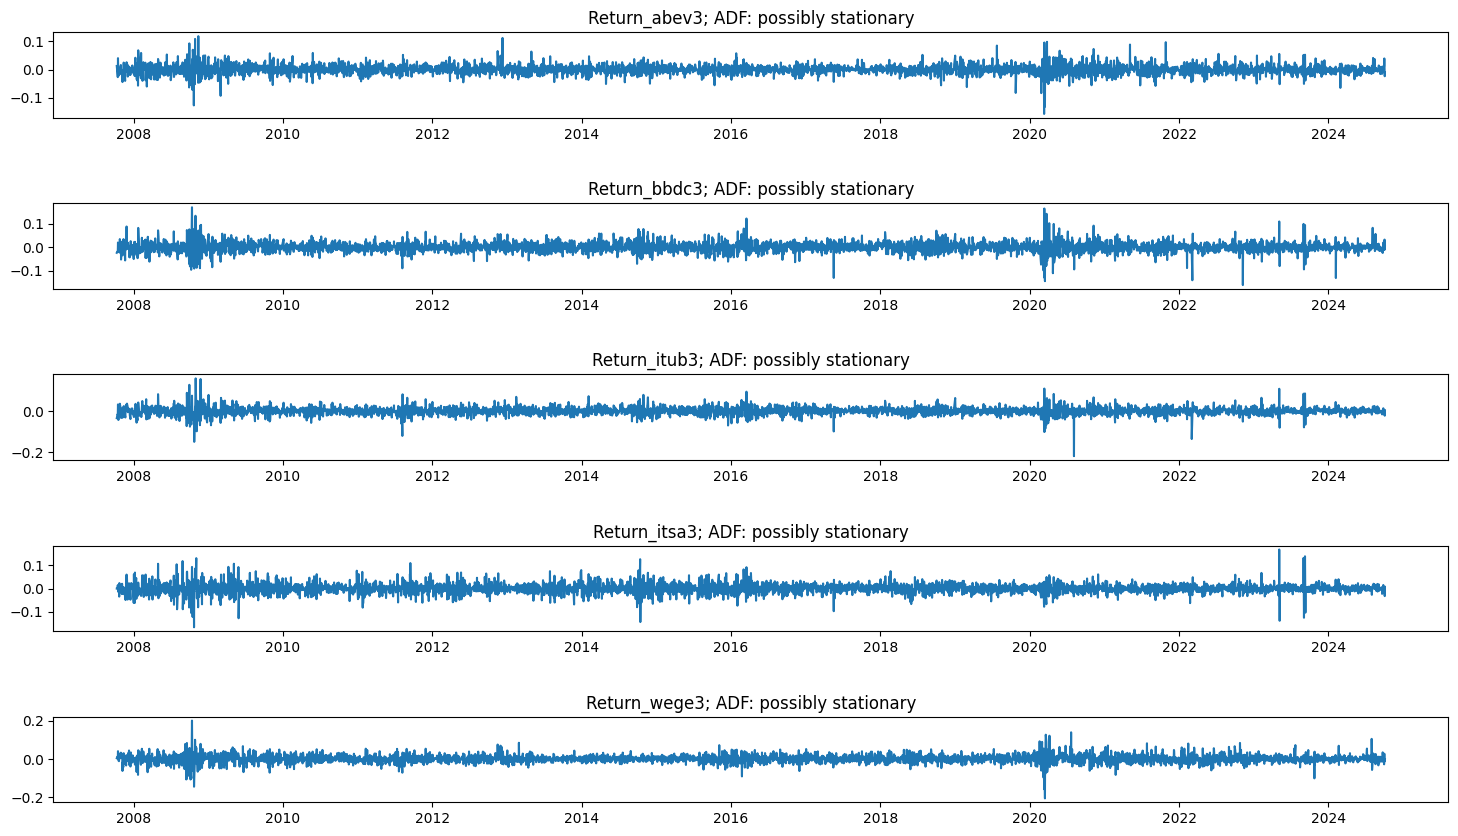

In [1372]:
plt.figure(figsize=(18, 10))
for i, col in enumerate([col for col in stocks_df.columns.tolist() if "Return_" in col]):

    _, p_value = adf_test(stocks_df[col])

    plt.subplot(5, 1, i+1)
    plt.axis(True)
    plt.plot(stocks_df[col])
    plt.title(f"{col}; ADF: {'possibly stationary' if p_value < 0.05 else 'possibly non-stationary'}")
    plt.subplots_adjust(wspace=0.2, hspace=1.0)

Shapiro-Wilk Statistic: 0.9404416071021598
P-Value: 3.4697772006833843e-38
H0 rejected, distribution can't be said Normal
Shapiro-Wilk Statistic: 0.9348584346672091
P-Value: 1.636872547307974e-39
H0 rejected, distribution can't be said Normal
Shapiro-Wilk Statistic: 0.9282654264966509
P-Value: 5.762905116915514e-41
H0 rejected, distribution can't be said Normal
Shapiro-Wilk Statistic: 0.9309156217723206
P-Value: 2.14475824132436e-40
H0 rejected, distribution can't be said Normal
Shapiro-Wilk Statistic: 0.9387577952727951
P-Value: 1.349519239688118e-38
H0 rejected, distribution can't be said Normal


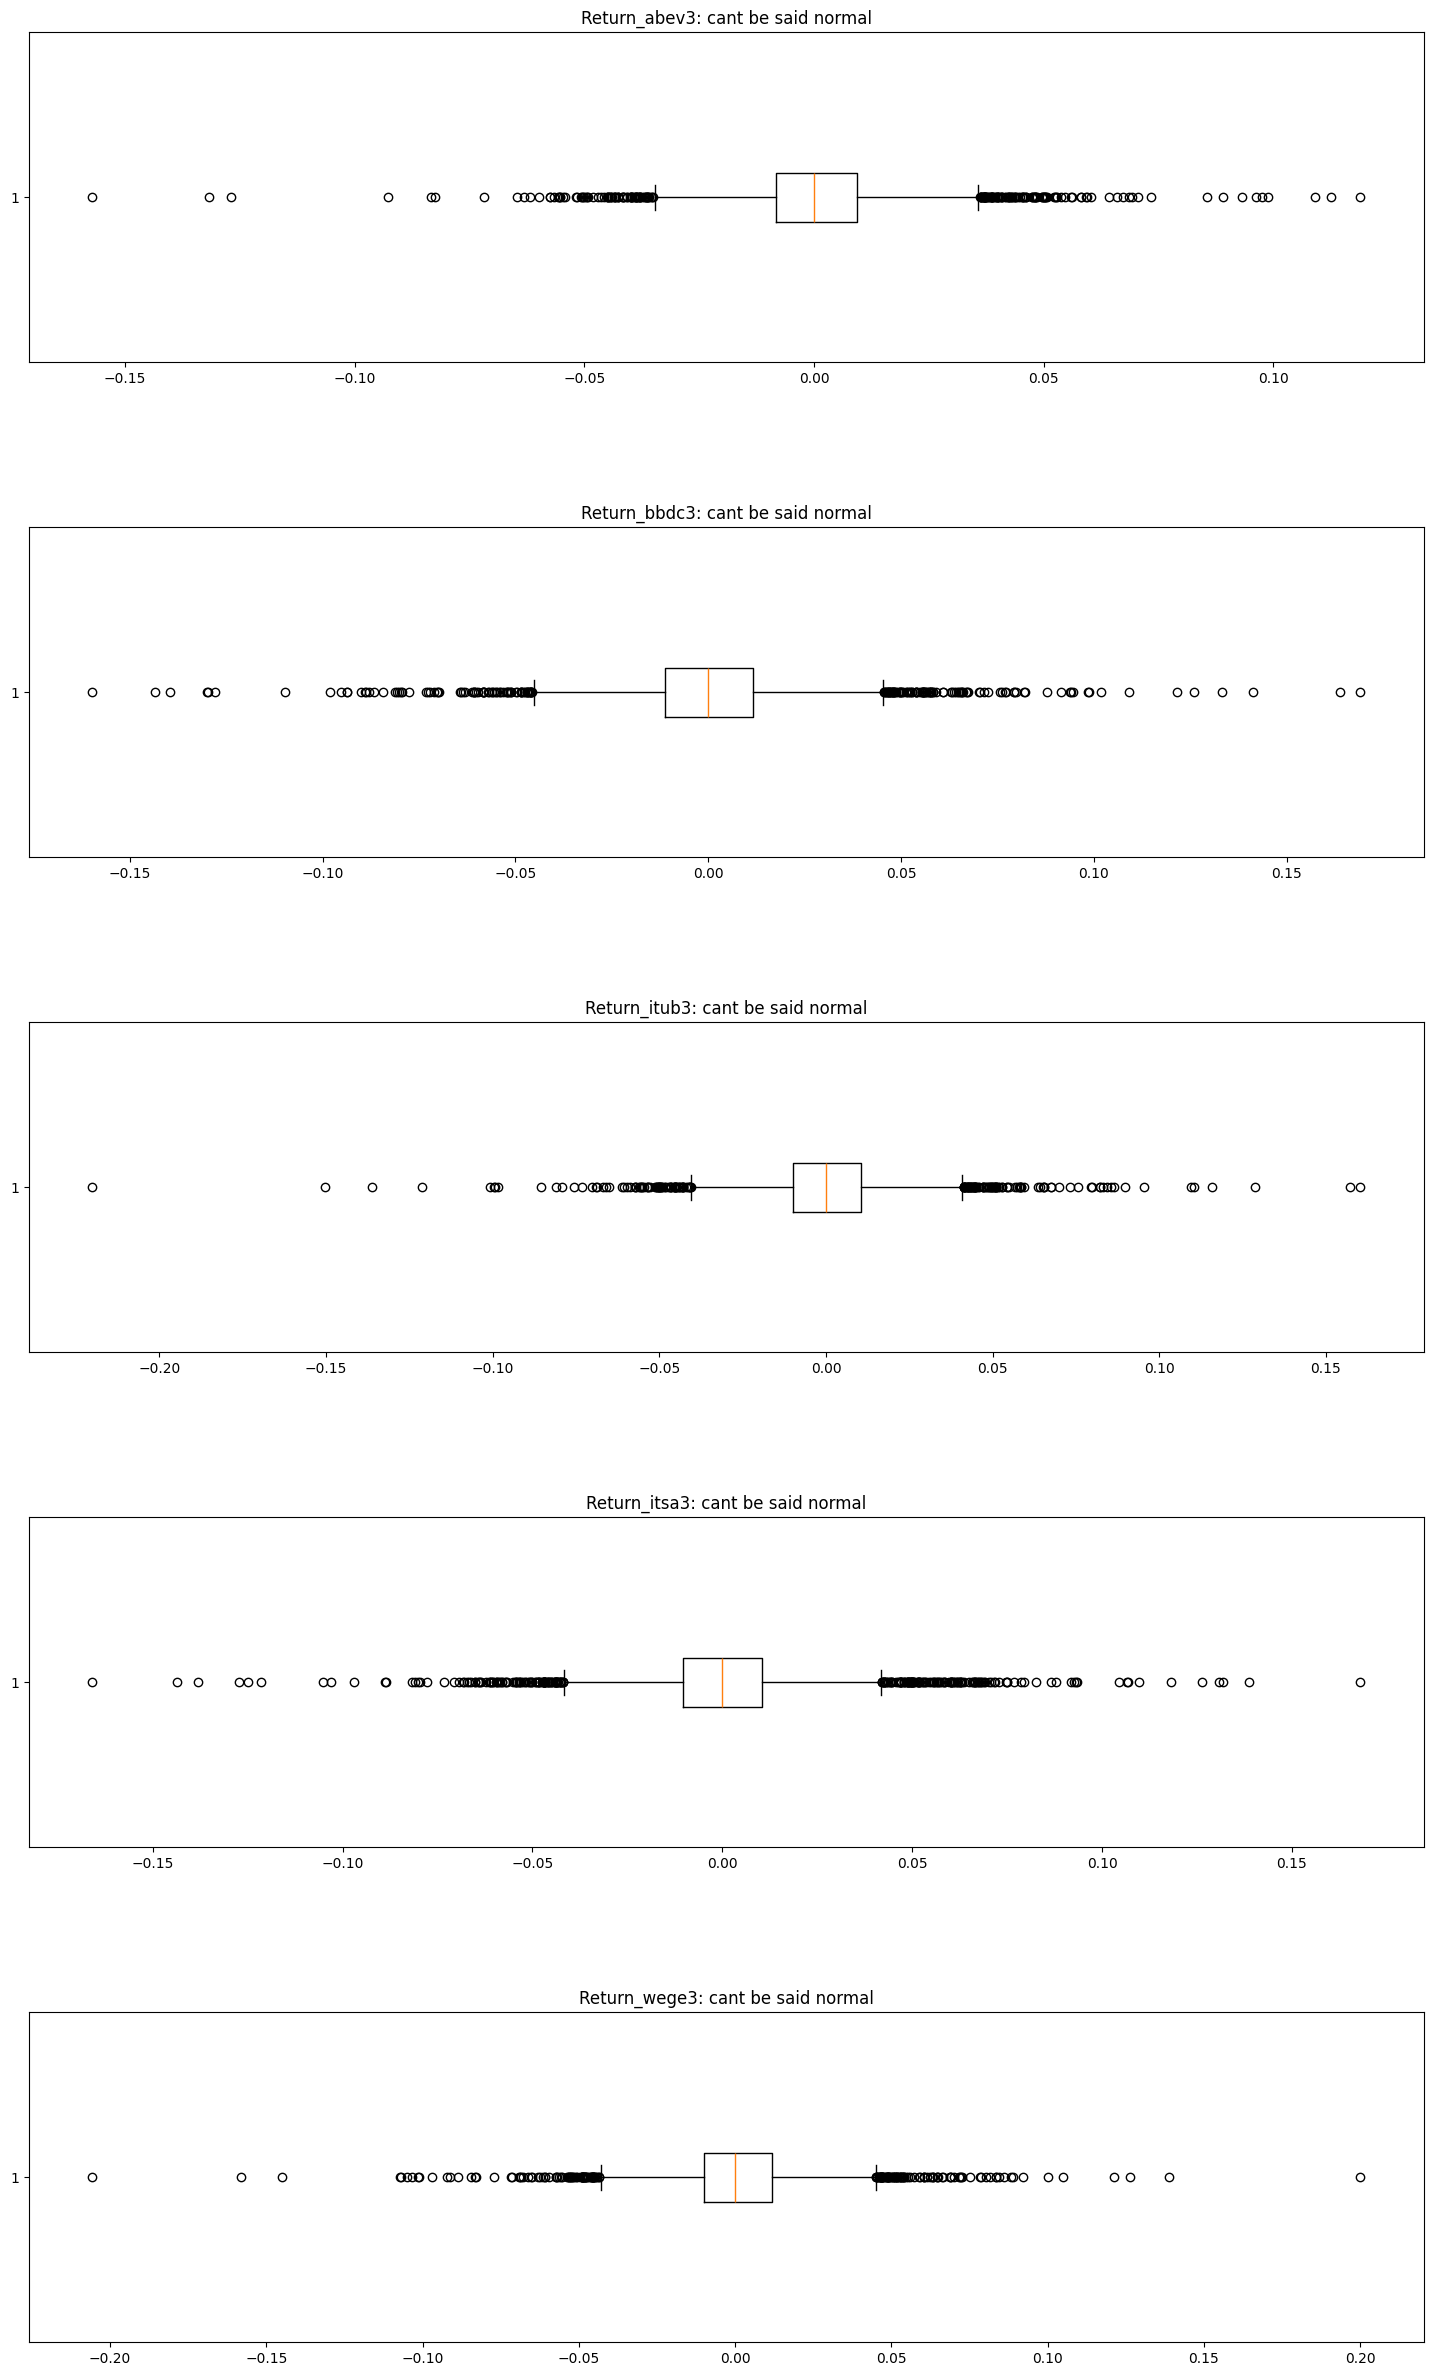

In [1373]:
plt.figure(figsize=(18, 30))
for i, col in enumerate([col for col in stocks_df.columns.tolist() if "Return_" in col]):

    _, p_value = shapiro_wilk_gaussian_test(stocks_df[col])

    plt.subplot(5, 1, i+1)
    plt.axis(True)
    plt.boxplot(stocks_df[col], vert=False)
    plt.title(f"{col}: {'cant be said normal' if p_value < 0.05 else 'possibly normal'}")
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

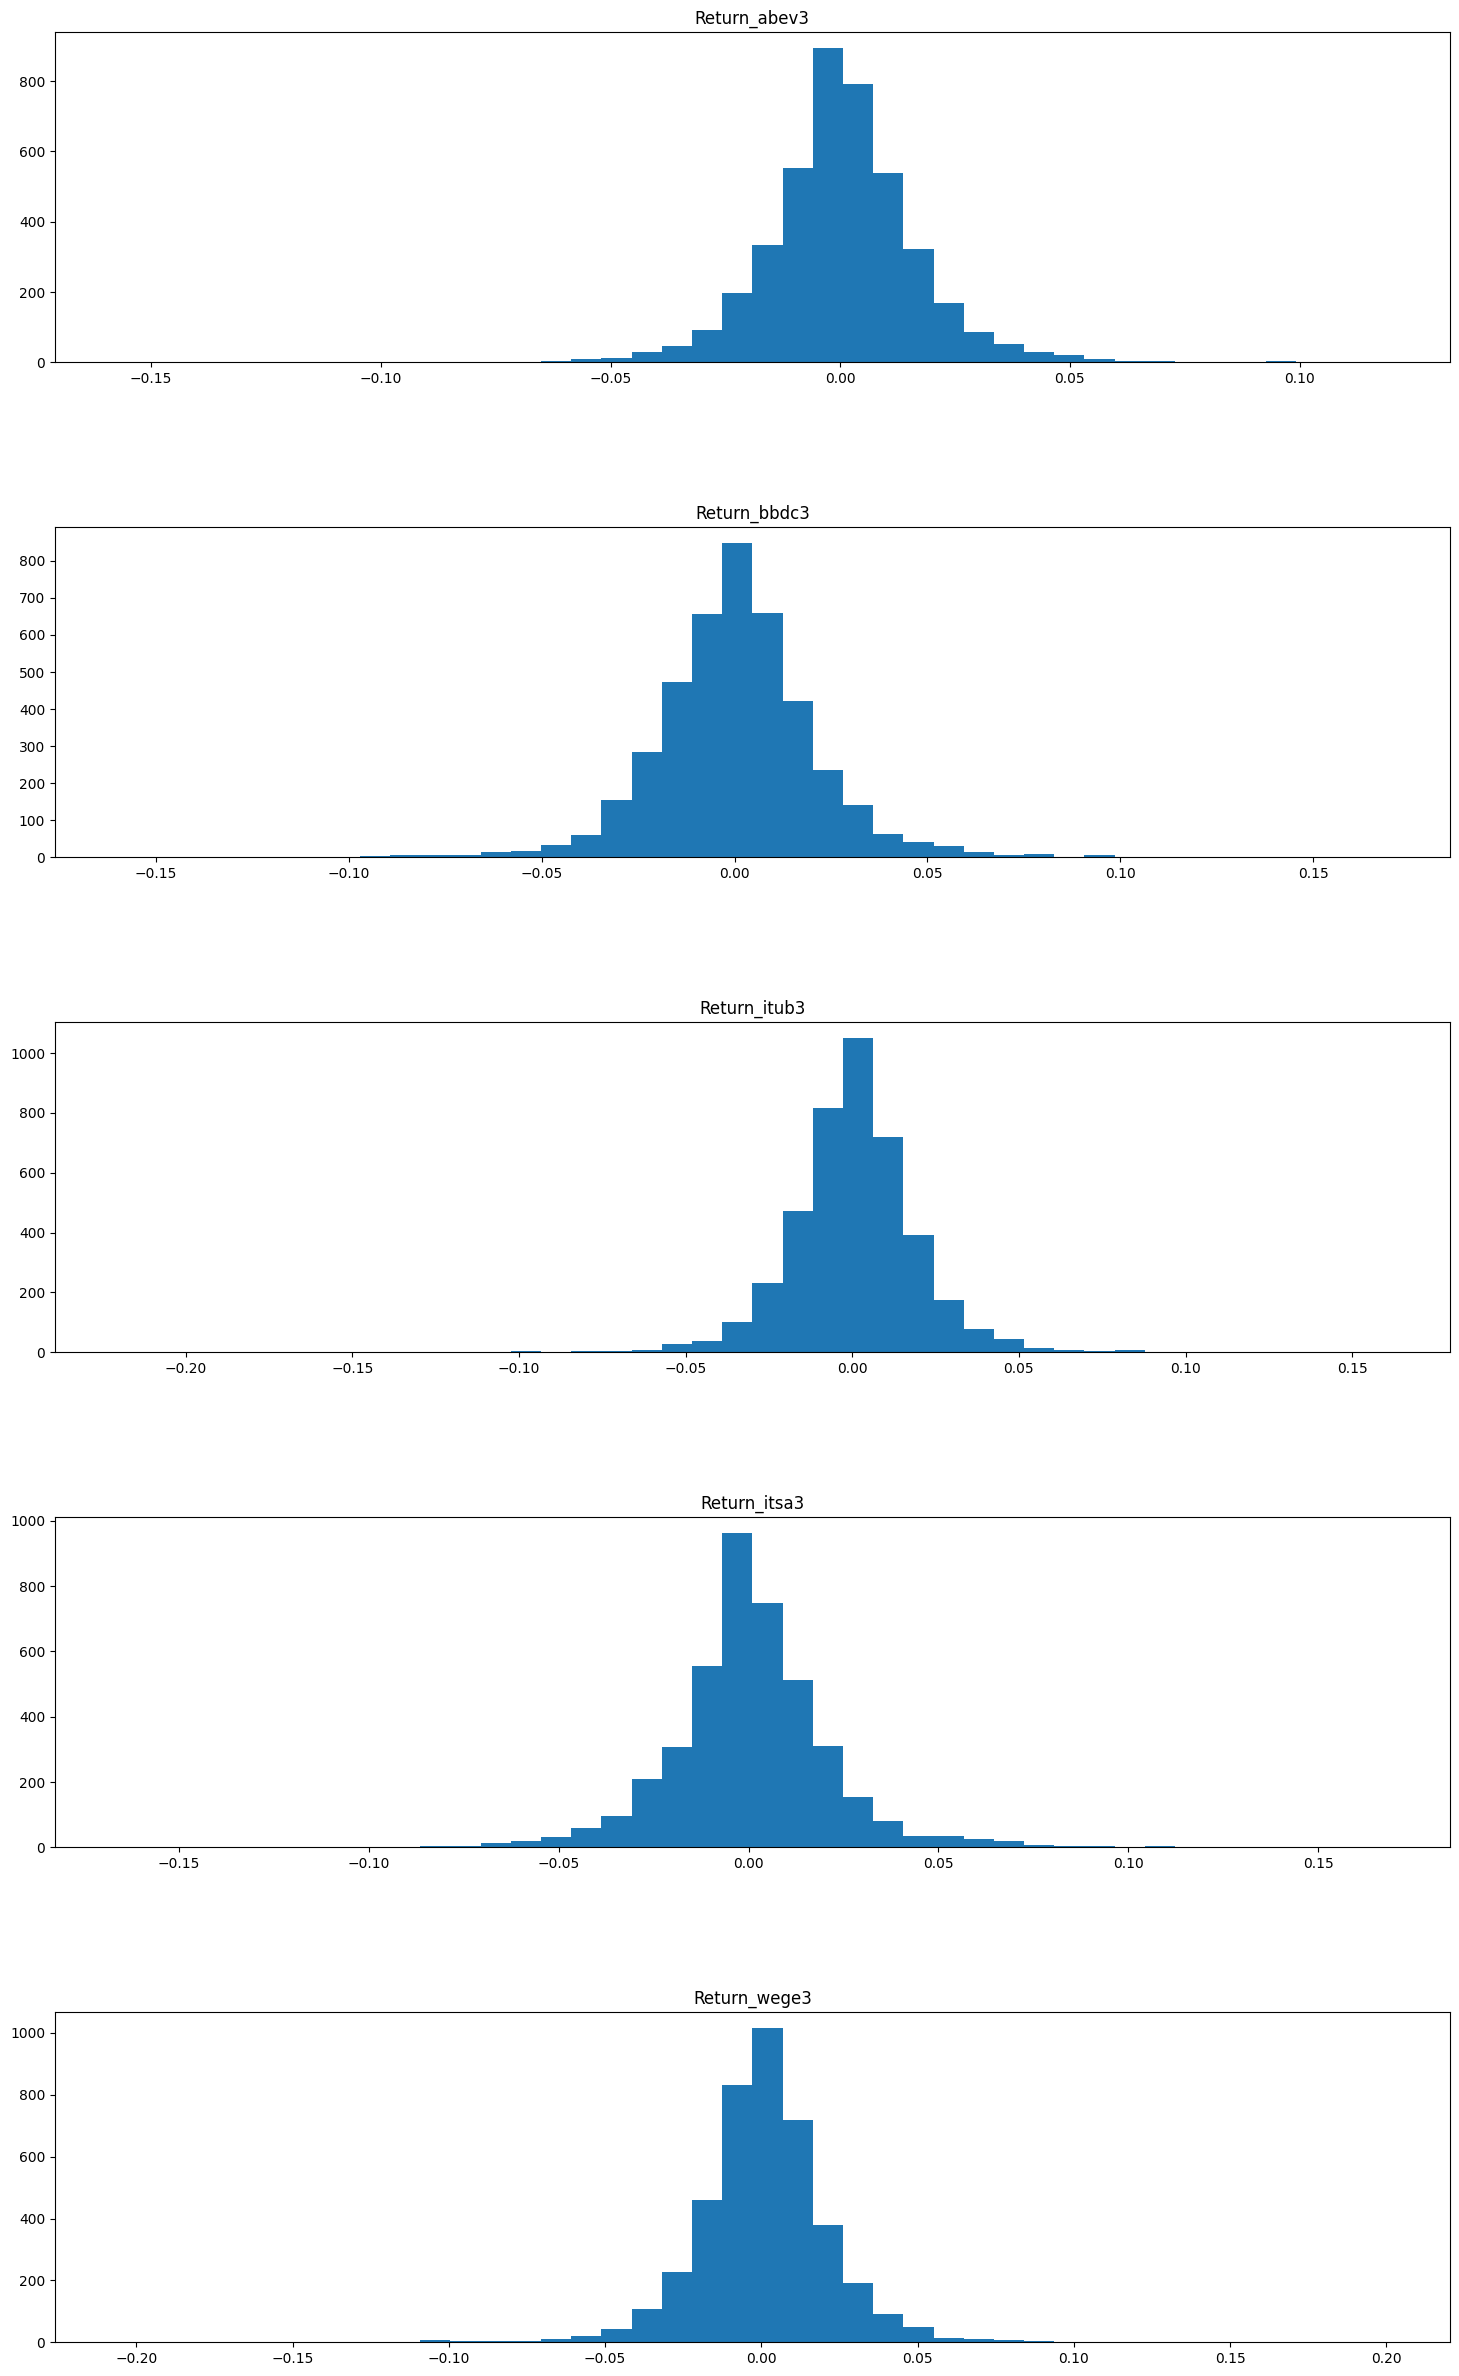

In [1374]:
plt.figure(figsize=(18, 30))
for i, col in enumerate([col for col in stocks_df.columns.tolist() if "Return_" in col]):

    plt.subplot(5, 1, i+1)
    plt.axis(True)
    plt.hist(stocks_df[col], bins=math.floor(len(stocks_df)/100))
    plt.title(col)
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

In [1375]:
return_cols_names = filter(lambda x: "Return_" in x, stocks_df.columns.tolist())
stocks_df[return_cols_names].describe()

,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3
count,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000
mean,0.000498,0.000419,0.000509,0.000508,0.000969
std,0.017163,0.022060,0.019777,0.021874,0.021406
min,-0.157168,-0.159763,-0.220203,-0.165992,-0.205761
25%,-0.008318,-0.011242,-0.009844,-0.010333,-0.010100
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.009434,0.011498,0.010580,0.010573,0.011955
max,0.118919,0.169014,0.160271,0.167989,0.200000


Returns series are all stationary and not normally distributed according to the ADF and Shapiro-Wilk test with mean slightly biased torward the positive side. The positive mean indicates that these series yielded positive returns more often than not, and buying and holding these stocks for this period of time would in the end result in a positive financial outcome. All series have outliers way above and below fences which may be influencing the SW test

In [1376]:
all_stocks_performance = stocks_df["Price_abev3"] + stocks_df["Price_bbdc3"] + stocks_df["Price_itub3"] + stocks_df["Price_itsa3"] + stocks_df["Price_wege3"]
px.line(all_stocks_performance)

# Experiments

In [1377]:
def plot_acf_figure(data):
    # Plot ACF (Autocorrelation Function)
    plt.figure(figsize=(24, 18))
    plot_acf(data, lags=40)
    plt.show()

def plot_pacf_figure(data):
    # Plot PACF (Partial Autocorrelation Function)
    plt.figure(figsize=(12, 6))
    plot_pacf(data, lags=40)
    plt.show()

## ARIMA

In [1378]:
# # Assuming your time series data is stored in a variable `data`
# # You can specify the number of lags you want (e.g., 40)
# abev3_pacf_values = pacf(stocks_df["Return_abev3"].dropna(), nlags=40, method='ywm')  # You can try 'ywm', 'ols', or 'ld' methods

# Print the PACF values
# for i in range(20):
#     print(f"value {i} greater than threshold: {abev3_pacf_values[i] > 0.05 or abev3_pacf_values[i] < -0.05}")


In [1379]:
# plot_acf_figure(stocks_df["Return_abev3"])

In [1380]:
# abev3_acf_values = acf(stocks_df["Return_abev3"], nlags=40)

# # Print the PACF values
# for i in range(10):
#     print(f"value {i} greater than threshold: {abev3_acf_values[i] > 0.05 or abev3_acf_values[i] < -0.05}")

Values for p and q are 1 and 2

#### Fitting the model

In [1381]:
# stocks_df.isna().sum()

In [1382]:
# abev3_return_series = stocks_df["Return_abev3"]
# abev3_arima = ARIMA(abev3_return_series)
# abev3_model_fit = abev3_arima.fit()

In [1383]:
# # summary of fit model
# print(abev3_model_fit.summary())
# # line plot of residuals
# abev3_residuals = pd.DataFrame(abev3_model_fit.resid)
# abev3_residuals.plot()
# plt.show()
# # density plot of residuals
# abev3_residuals.plot(kind='kde')
# plt.show()
# # summary stats of residuals
# print(abev3_residuals.describe())

In [1384]:
# normal_komolgorov_smirnov(abev3_residuals)

In [1385]:
# train, test = train_test_split(abev3_return_series, test_size=0.3)
# model = pm.auto_arima(train)

# forecasts = model.predict(test.shape[0])  # predict N steps into the future

# # Visualize the forecasts (blue=train, green=forecasts)
# x = np.arange(abev3_return_series.shape[0])
# plt.plot(x[:len(train)], train, c='blue')
# plt.plot(x[len(train):], forecasts, c='green')
# plt.show()


In [1386]:
# plot_acf_figure(abev3_residuals)

In [1387]:
# residuals_acf_values = acf(abev3_residuals, nlags=40)

# # Print the PACF values
# for i in range(40):
#     print(f"value {i} greater than threshold: {residuals_acf_values[i] > 0.05 or residuals_acf_values[i] < -0.05}")

Residuals present a peaked bell shaped curve but cannot be assumed to be normally distributed. Mean is biased torward the negative end 

In [1388]:
# abev3["Ground_y"] = abev3["Return"].shift(1)
# abev3.head()

In [1389]:
# abev3.tail()

In [1390]:
# TRAIN_LEN = 1735

# def run_arima_over_dataset(df: pd.DataFrame, order: tuple[int, int, int]):

#     y_hat = np.array([None for _ in range(6)])
#     train = np.flip(df["Return"].to_numpy())
#     print(train)
#     print(y_hat)

#     for i in range(0, len(df) - 6):
#         model = ARIMA(train[:i+5], order=order)
#         fitted = model.fit()
#         y_pred = fitted.forecast()
#         # y_hat.append(y_pred)
#         y_hat = np.append(y_hat, y_pred)
    
#     df["y_hat"] = np.flip(y_hat)

In [1391]:
def print_metrics(y_pred, y_true, title):
    print(f"prediction accuracy for {title}: {accuracy_score(y_true, y_pred)}")
    print(f"prediction precision for {title}: {precision_score(y_true, y_pred)}")
    print(f"prediction recall for {title}: {recall_score(y_true, y_pred)}")
    print(f"prediction f1 for {title}: {f1_score(y_true, y_pred)}")

In [1392]:
def plot_cm(y_true, y_pred, title='Confusion Matrix'):
  # Calculate confusion matrix
  cm = confusion_matrix(y_true, y_pred)

  # Plotting the confusion matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.title(title)
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

In [1393]:
# run_arima_over_dataset(abev3, (1, 0, 2))
# abev3.tail()

# Building Dataframe

In [1394]:
def compute_lags(df: pd.DataFrame, column_names: list[str]):
    for col in column_names:
        if "Return" in col:
            for i in range(5):
                df[f"{col}_lag_{i+1}"] = df[f"{col}"].shift(i+1)

In [1395]:
def compute_targets(df: pd.DataFrame, column_names: list[str]):
    df["Cross_sectional_median"] = np.median(df[[col for col in column_names if "Return" in col and not "lag" in col and not "Class" in col]].to_numpy(), axis=1)

    df["abev3_y"] = df["Return_abev3"] > df["Cross_sectional_median"]
    df["bbdc3_y"] = df["Return_bbdc3"] > df["Cross_sectional_median"]
    df["itsa3_y"] = df["Return_itsa3"] > df["Cross_sectional_median"]
    df["itub3_y"] = df["Return_itub3"] > df["Cross_sectional_median"]
    df["wege3_y"] = df["Return_wege3"] > df["Cross_sectional_median"]

In [1396]:
compute_lags(stocks_df, stocks_df.columns.tolist())

stocks_df.head()

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3,...,Return_itsa3_lag_1,Return_itsa3_lag_2,Return_itsa3_lag_3,Return_itsa3_lag_4,Return_itsa3_lag_5,Return_wege3_lag_1,Return_wege3_lag_2,Return_wege3_lag_3,Return_wege3_lag_4,Return_wege3_lag_5
Date,,,,,,,,,,,,,,,,,,,,,
2007-10-11,3.08,6.20,7.87,3.43,2.44,0.013158,-0.023622,-0.034356,0.000000,0.004115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-10-15,3.02,6.09,7.75,3.43,2.47,-0.019481,-0.017742,-0.015248,0.000000,0.012295,...,0.000000,NaN,NaN,NaN,NaN,0.004115,NaN,NaN,NaN,NaN
2007-10-16,2.94,5.97,7.61,3.48,2.47,-0.026490,-0.019704,-0.018065,0.014577,0.000000,...,0.000000,0.000000,NaN,NaN,NaN,0.012295,0.004115,NaN,NaN,NaN
2007-10-17,3.06,6.09,7.86,3.48,2.57,0.040816,0.020101,0.032852,0.000000,0.040486,...,0.014577,0.000000,0.0,NaN,NaN,0.000000,0.012295,0.004115,NaN,NaN
2007-10-18,3.07,6.09,7.86,3.48,2.59,0.003268,0.000000,0.000000,0.000000,0.007782,...,0.000000,0.014577,0.0,0.0,NaN,0.040486,0.000000,0.012295,0.004115,NaN


In [1397]:
compute_targets(stocks_df, stocks_df.columns.tolist())
stocks_df.head(15)

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3,...,Return_wege3_lag_2,Return_wege3_lag_3,Return_wege3_lag_4,Return_wege3_lag_5,Cross_sectional_median,abev3_y,bbdc3_y,itsa3_y,itub3_y,wege3_y
Date,,,,,,,,,,,,,,,,,,,,,
2007-10-11,3.08,6.20,7.87,3.43,2.44,0.013158,-0.023622,-0.034356,0.000000,0.004115,...,NaN,NaN,NaN,NaN,0.000000,True,False,False,False,True
2007-10-15,3.02,6.09,7.75,3.43,2.47,-0.019481,-0.017742,-0.015248,0.000000,0.012295,...,NaN,NaN,NaN,NaN,-0.015248,False,False,True,False,True
2007-10-16,2.94,5.97,7.61,3.48,2.47,-0.026490,-0.019704,-0.018065,0.014577,0.000000,...,0.004115,NaN,NaN,NaN,-0.018065,False,False,True,False,True
2007-10-17,3.06,6.09,7.86,3.48,2.57,0.040816,0.020101,0.032852,0.000000,0.040486,...,0.012295,0.004115,NaN,NaN,0.032852,True,False,False,False,True
2007-10-18,3.07,6.09,7.86,3.48,2.59,0.003268,0.000000,0.000000,0.000000,0.007782,...,0.000000,0.012295,0.004115,NaN,0.000000,True,False,False,False,True
2007-10-19,3.00,6.09,7.52,3.43,2.57,-0.022801,0.000000,-0.043257,-0.014368,-0.007722,...,0.040486,0.000000,0.012295,0.004115,-0.014368,False,True,False,False,True
2007-10-22,3.00,6.13,7.57,3.50,2.54,0.000000,0.006568,0.006649,0.020408,-0.011673,...,0.007782,0.040486,0.000000,0.012295,0.006568,False,False,True,True,False
2007-10-23,3.00,6.19,7.70,3.38,2.58,0.000000,0.009788,0.017173,-0.034286,0.015748,...,-0.007722,0.007782,0.040486,0.000000,0.009788,False,False,False,True,True
2007-10-24,3.00,6.23,7.59,3.46,2.65,0.000000,0.006462,-0.014286,0.023669,0.027132,...,-0.011673,-0.007722,0.007782,0.040486,0.006462,False,False,True,False,True
